# Histogram task tied exp

In [36]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
import os

In [37]:
run_id = "20251126_1019" # 5 - 10 - 15

run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

## 1. experiment config

In [38]:
# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

⚙️ Config loaded (15 rows) from ../results/run_20251126_1019/config.csv


,D,L,T,d_mlp_list,alpha,rho,beta,lambda,samples,max_iter,...,device,logger,run_dir,run_index,seed,batch_size,R,N_train,N_total,MLP_dim
0,100,15,30,[30],0.050000,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_0_2735010 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,0,42,64,100,500,4500,30
1,100,15,30,[30],0.082143,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_1_2735011 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,1,42,64,100,821,4821,30
2,100,15,30,[30],0.114286,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_2_2735012 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,2,42,64,100,1142,5142,30
3,100,15,30,[30],0.146429,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_3_2735013 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,3,42,64,100,1464,5464,30
4,100,15,30,[30],0.178571,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_4_2735014 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,4,42,64,100,1785,5785,30
5,100,15,30,[30],0.210714,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_5_2735015 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,5,42,64,100,2107,6107,30
6,100,15,30,[30],0.275000,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_7_2735017 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,7,42,64,100,2750,6750,30
7,100,15,30,[30],0.242857,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_6_2735016 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,6,42,64,100,2428,6428,30
8,100,15,30,[30],0.307143,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_8_2735018 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,8,42,64,100,3071,7071,30
9,100,15,30,[30],0.371429,1.0,1.0,0.0001,12,5000,...,cuda,<Logger logger_10_2735020 (DEBUG)>,/home/peucelle/tpiv-simulations/results/run_20...,10,42,64,100,3714,7714,30


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (15 rows) from ../results/run_20251126_1019/summary.csv


,alpha,MLP_dim,rho,label_err_mean,label_err_std,train_data_mean,train_reg_mean,train_total_mean,acc_test_mean,acc_test_std,acc_train_mean,acc_train_std,rank_before_mean,rank_before_std,rank_after_mean,rank_after_std
0,0.050000,30,1.0,0.000482,0.000240,0.000246,0.000057,0.000303,0.307547,0.078012,0.345884,0.076482,93.666667,4.417596,85.250000,8.378815
1,0.082143,30,1.0,0.000512,0.000145,0.000314,0.000057,0.000371,0.287744,0.048979,0.315997,0.047823,90.750000,6.166257,81.083333,8.240238
2,0.114286,30,1.0,0.000406,0.000187,0.000272,0.000057,0.000329,0.326544,0.064314,0.356459,0.078455,87.583333,7.739607,79.583333,11.261022
3,0.146429,30,1.0,0.000236,0.000076,0.000180,0.000056,0.000236,0.403358,0.071890,0.416556,0.062227,84.000000,10.987596,70.416667,13.055534
4,0.178571,30,1.0,0.000262,0.000080,0.000203,0.000054,0.000257,0.400558,0.067760,0.406244,0.062741,87.333333,9.028574,74.916667,8.670308


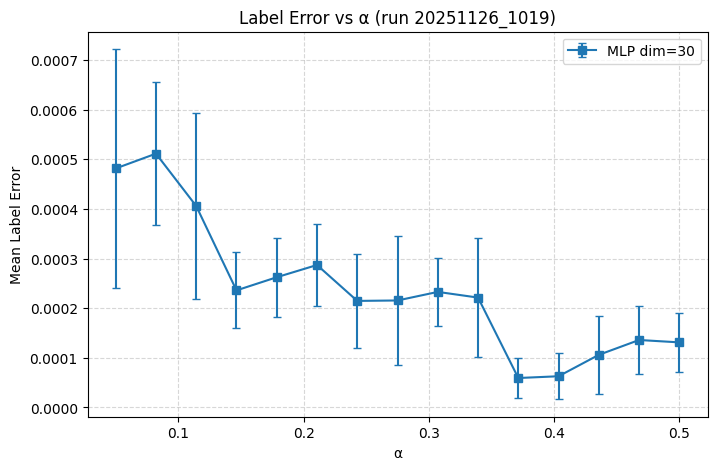

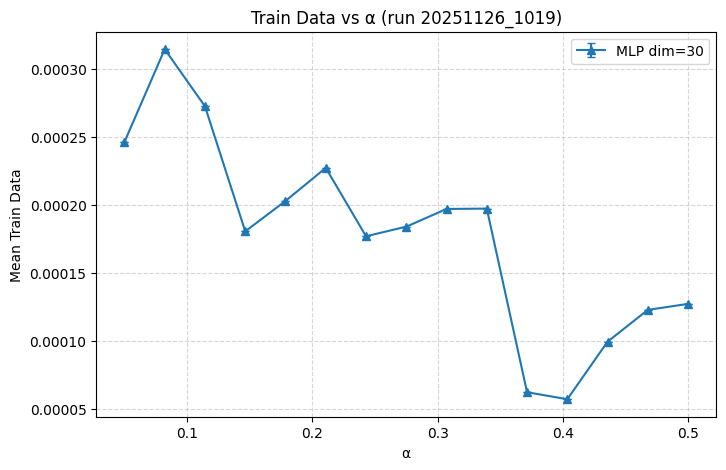

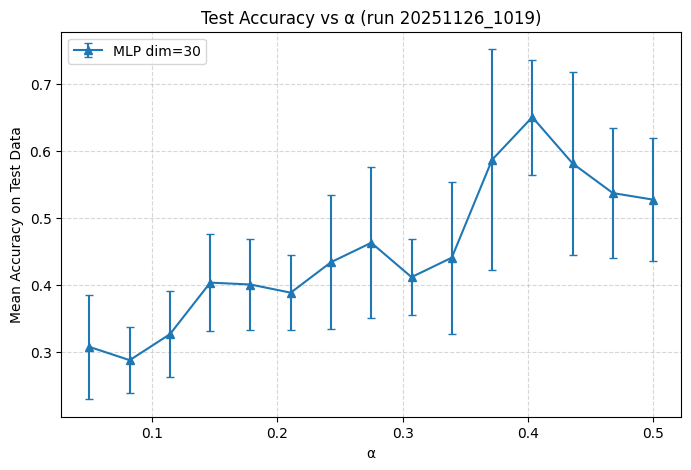

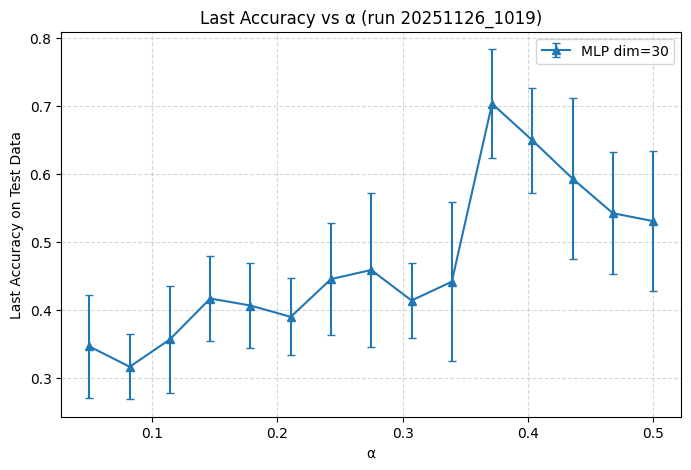

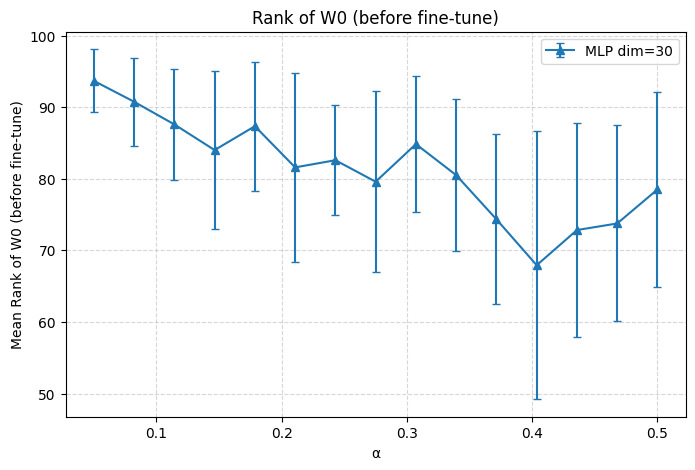

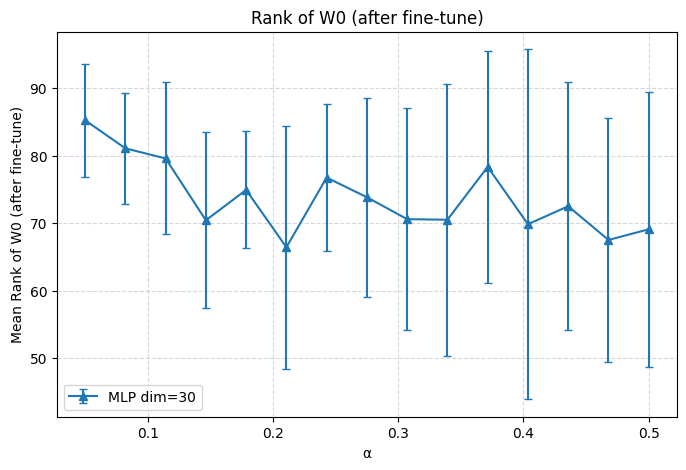

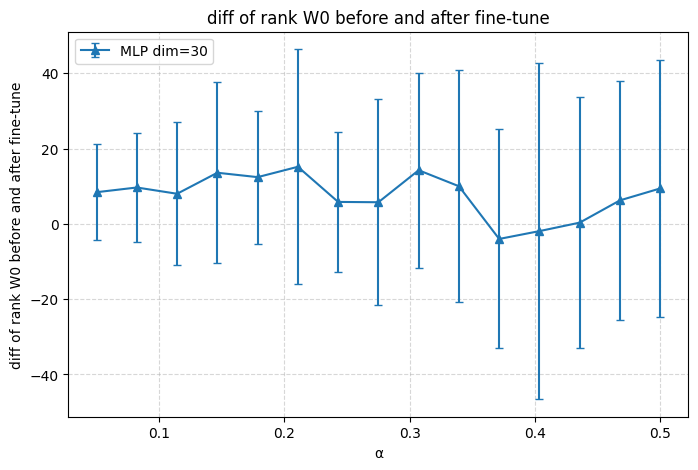

In [39]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

# --- Plot Label Error vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["label_err_mean"], yerr=subset.get("label_err_std", 0),
                 marker='s', capsize=3, label=f"MLP dim={MLP_dim}")
plt.xlabel("α")
plt.ylabel("Mean Label Error")
plt.title(f"Label Error vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["train_data_mean"], yerr=subset.get("train_data_std", 0),
                 marker='^', capsize=3, label=f"MLP dim={MLP_dim}")
plt.xlabel("α")
plt.ylabel("Mean Train Data")
plt.title(f"Train Data vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["acc_test_mean"], yerr=subset.get("acc_test_std", 0),
                 marker='^', capsize=3, label=f"MLP dim={MLP_dim}")
plt.xlabel("α")
plt.ylabel("Mean Accuracy on Test Data")
plt.title(f"Test Accuracy vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["acc_train_mean"], yerr=subset.get("acc_train_std", 0),
                 marker='^', capsize=3, label=f"MLP dim={MLP_dim}")
    #plt.plot(subset["alpha"], subset["acc_train_last"], linestyle='--', alpha=0.7)
plt.xlabel("α")
plt.ylabel("Last Accuracy on Test Data")
plt.title(f"Last Accuracy vs α (run {run_id})")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- rank before fine tune---
plt.figure(figsize=(8, 5))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["rank_before_mean"], yerr=subset.get("rank_before_std", 0),
                 marker='^', capsize=3, label=f"MLP dim={MLP_dim}")
plt.xlabel("α")
plt.ylabel("Mean Rank of W0 (before fine-tune)")
plt.title("Rank of W0 (before fine-tune)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- rank after fine tune ---
plt.figure(figsize=(8, 5))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["rank_after_mean"], yerr=subset.get("rank_after_std", 0),
                 marker='^', capsize=3, label=f"MLP dim={MLP_dim}")
plt.xlabel("α")
plt.ylabel("Mean Rank of W0 (after fine-tune)")
plt.title("Rank of W0 (after fine-tune)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# --- diff rank ---
plt.figure(figsize=(8, 5))
for MLP_dim in sorted(df["MLP_dim"].unique()):
    subset = df[df["MLP_dim"] == MLP_dim].sort_values("alpha")
    plt.errorbar(subset["alpha"],  subset["rank_before_mean"]-subset["rank_after_mean"], yerr= subset.get("rank_before_std", 0)+subset.get("rank_after_std", 0),
                 marker='^', capsize=3, label=f"MLP dim={MLP_dim}")
plt.xlabel("α")
plt.ylabel("diff of rank W0 before and after fine-tune")
plt.title("diff of rank W0 before and after fine-tune")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3. Results visualisation

Found 15 heavy_data files.

--- File: ../results/run_20251126_1019/heavy_data_0.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 42.397636


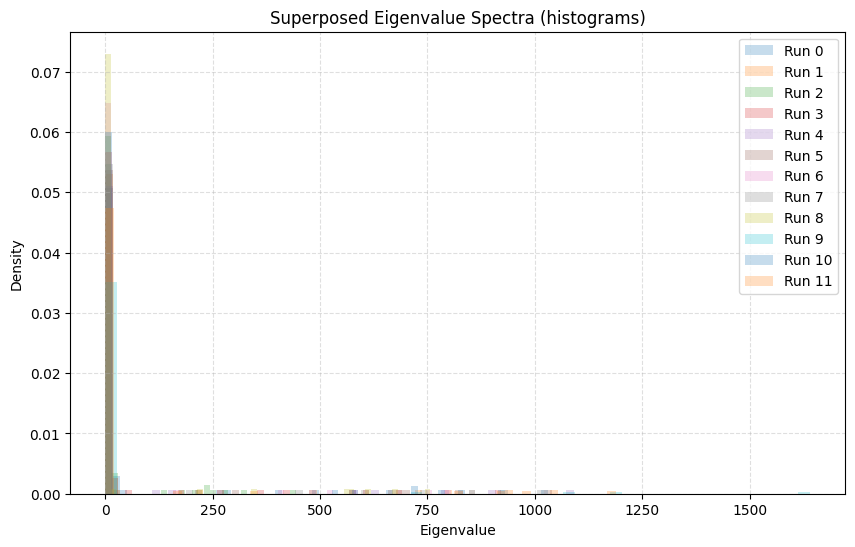

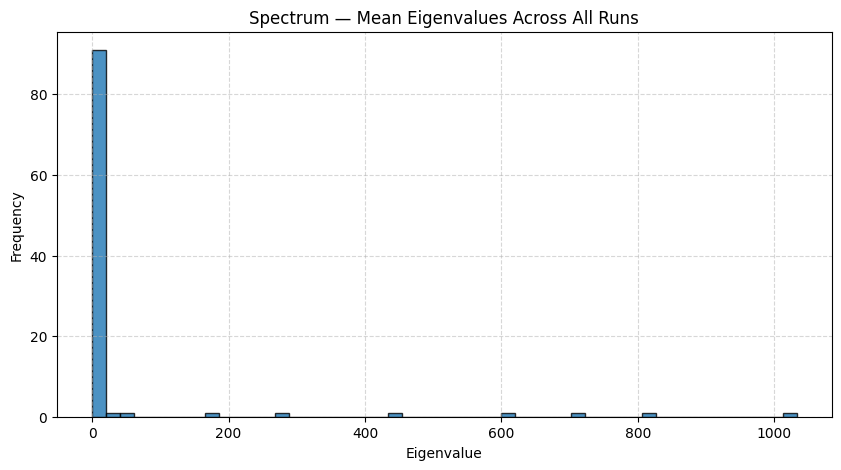

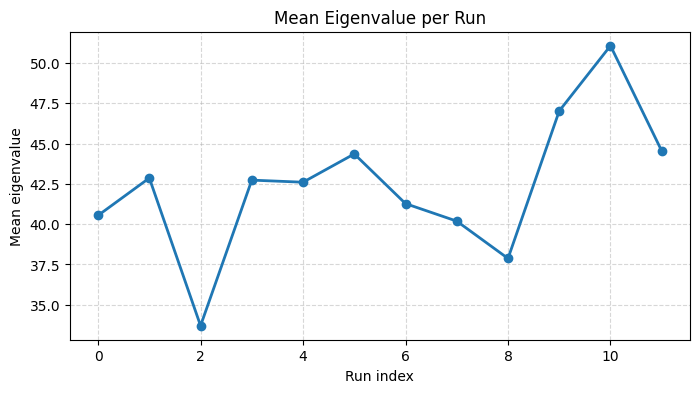

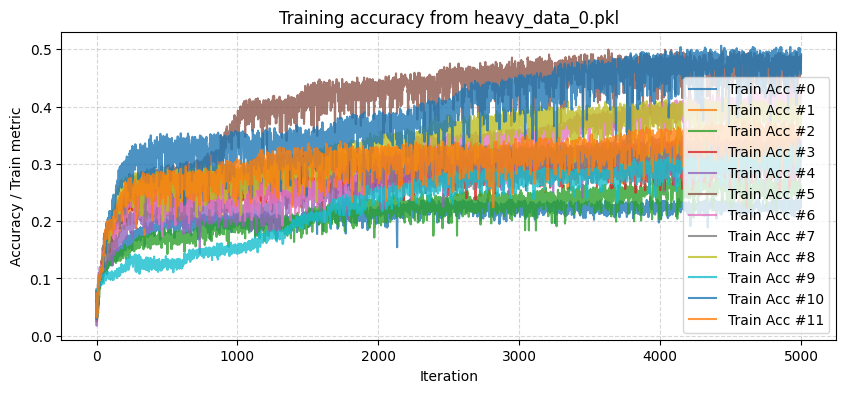

--- File: ../results/run_20251126_1019/heavy_data_1.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 37.590744


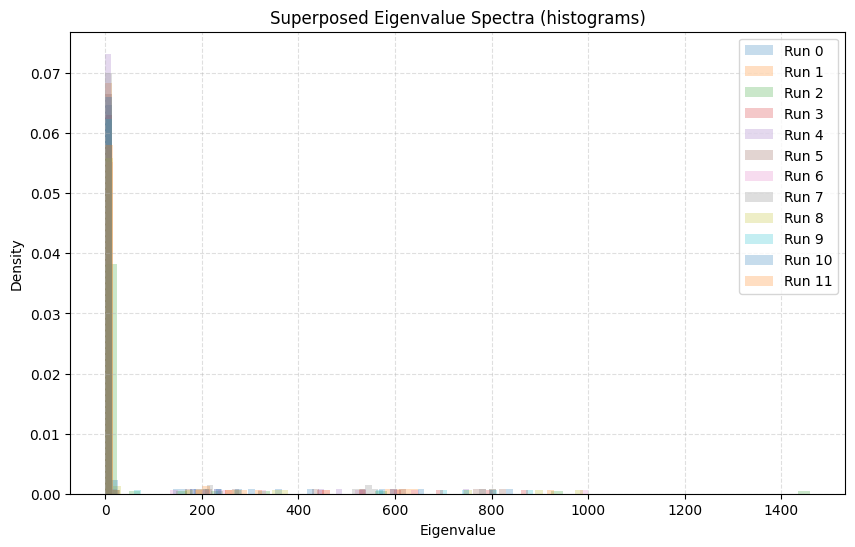

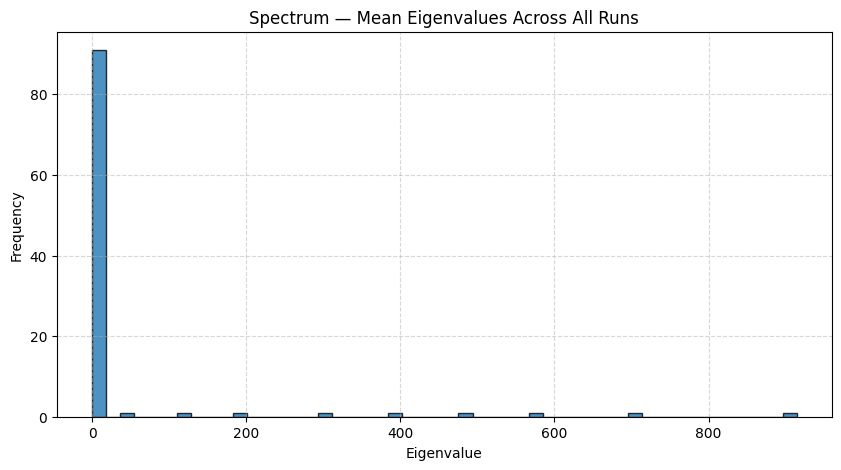

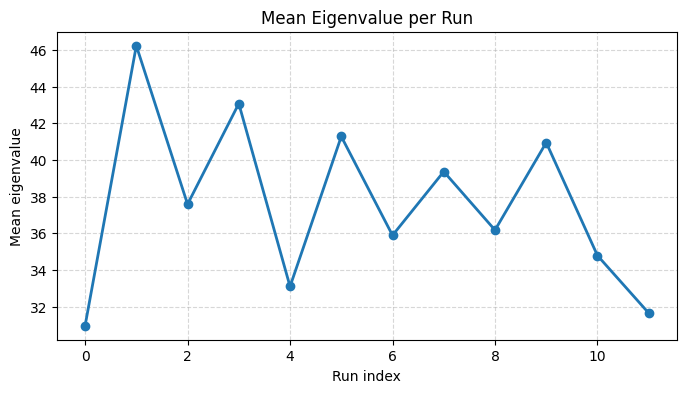

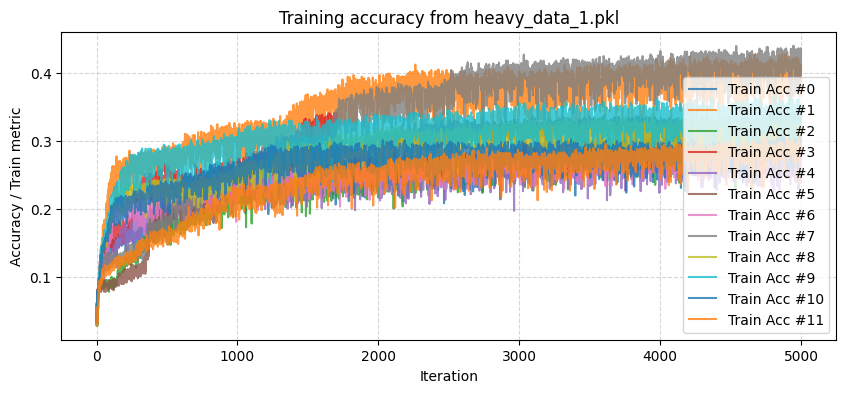

--- File: ../results/run_20251126_1019/heavy_data_10.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 35.372810


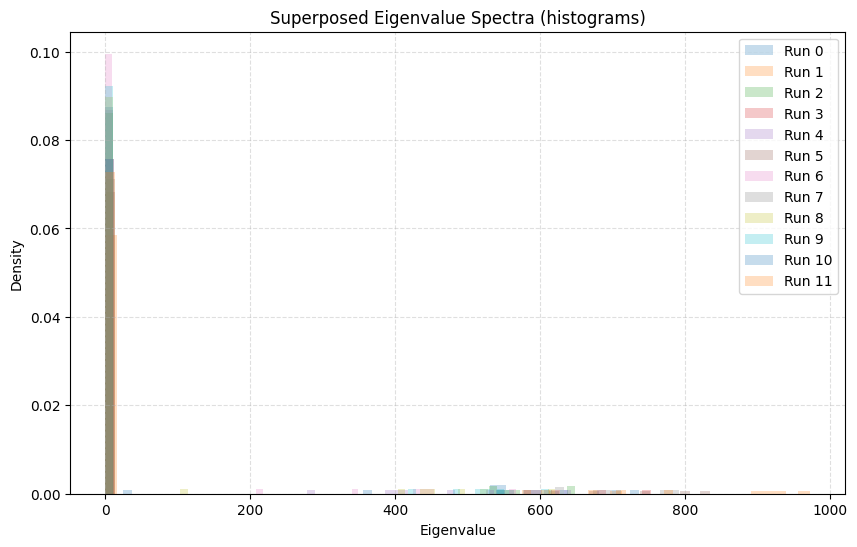

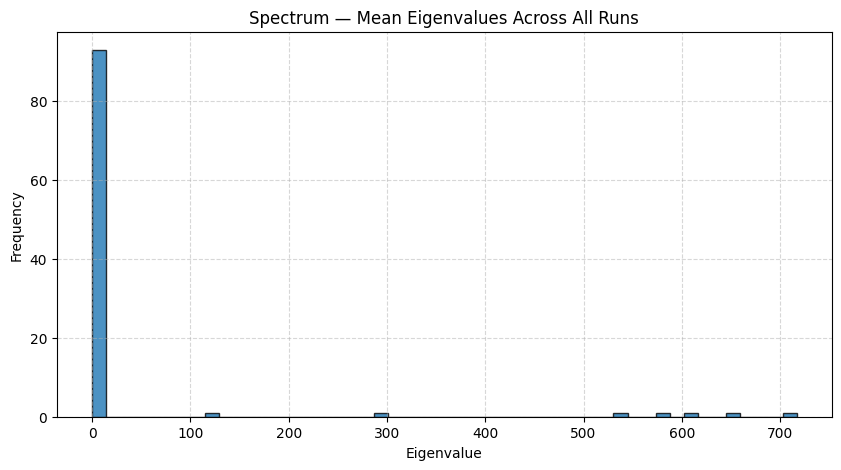

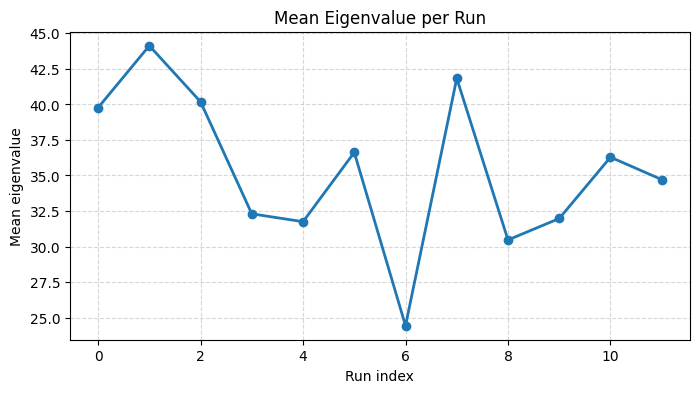

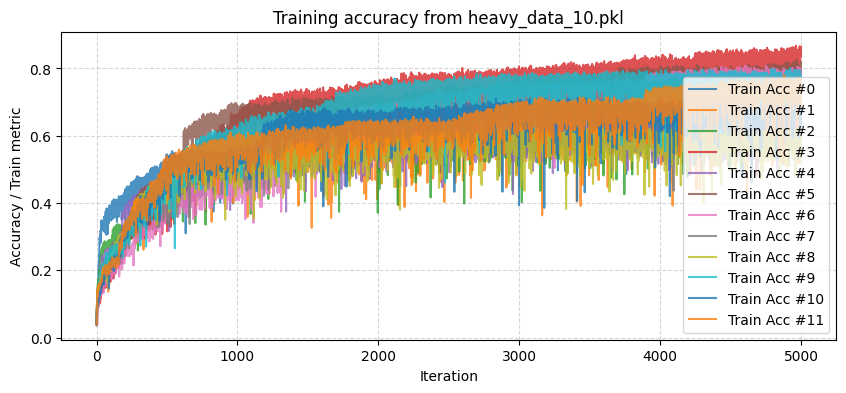

--- File: ../results/run_20251126_1019/heavy_data_11.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 37.389130


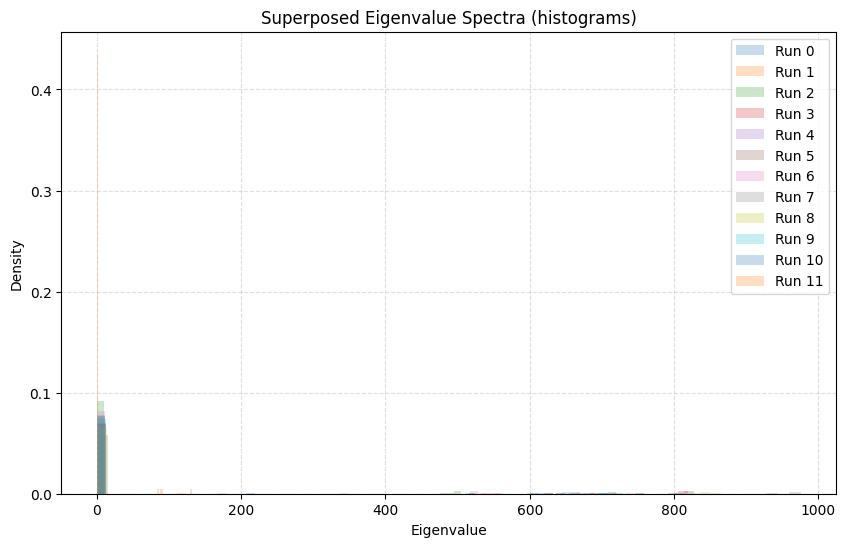

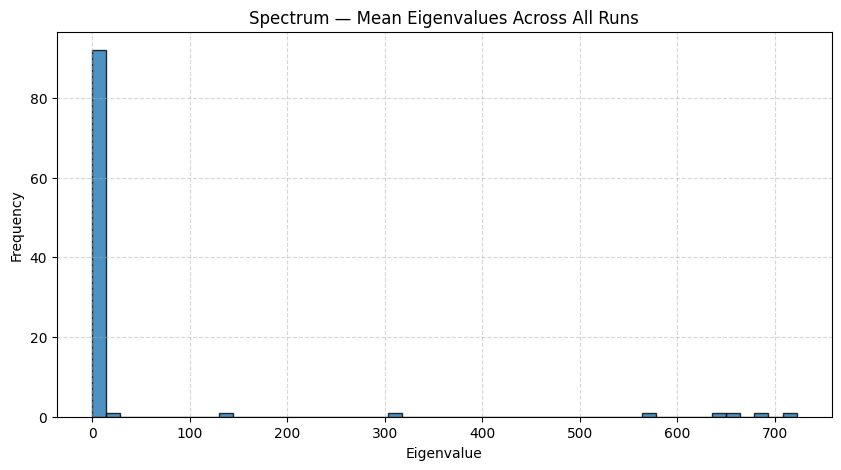

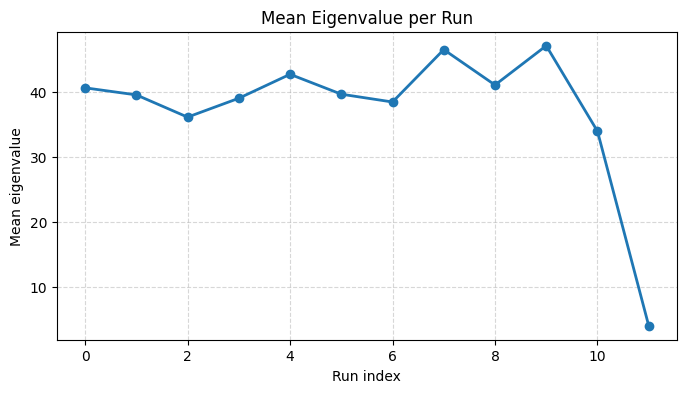

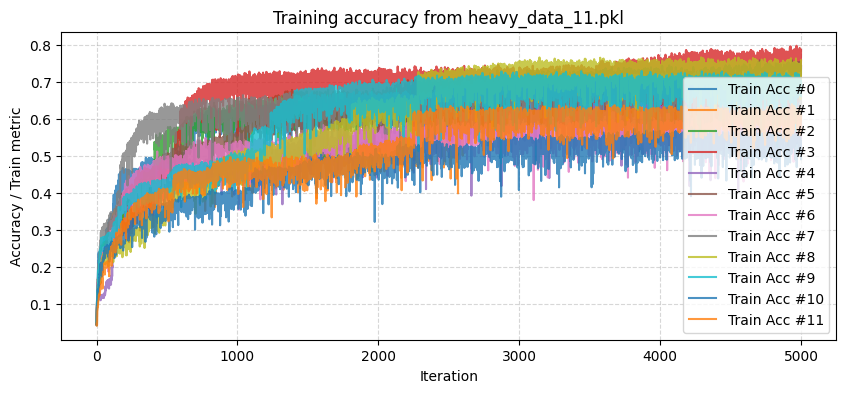

--- File: ../results/run_20251126_1019/heavy_data_12.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 37.079788


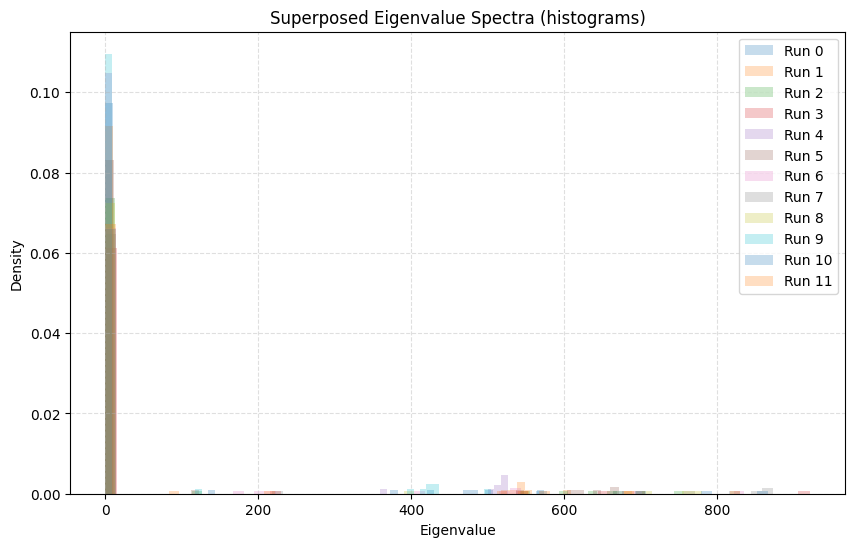

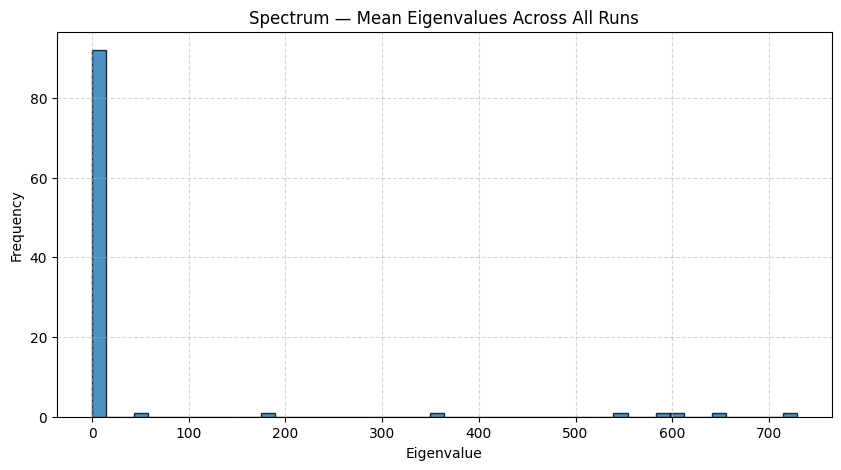

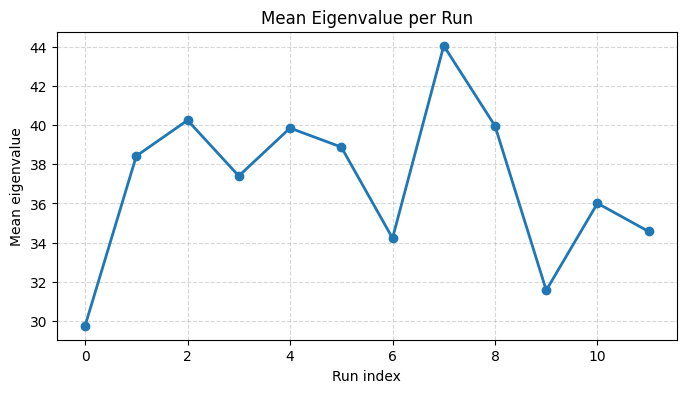

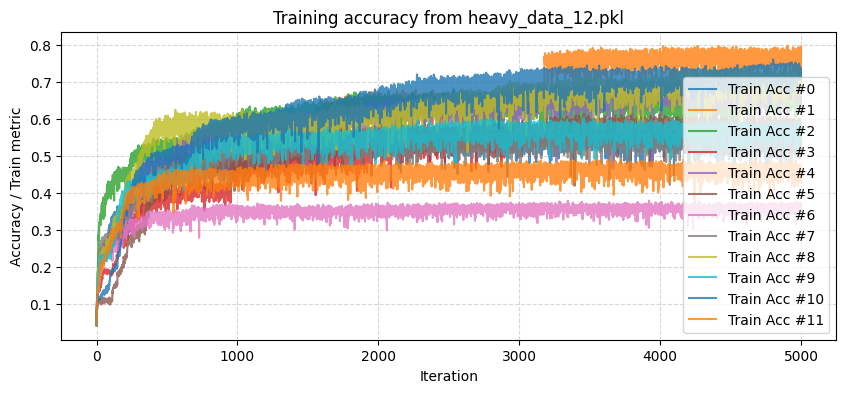

--- File: ../results/run_20251126_1019/heavy_data_13.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 36.151443


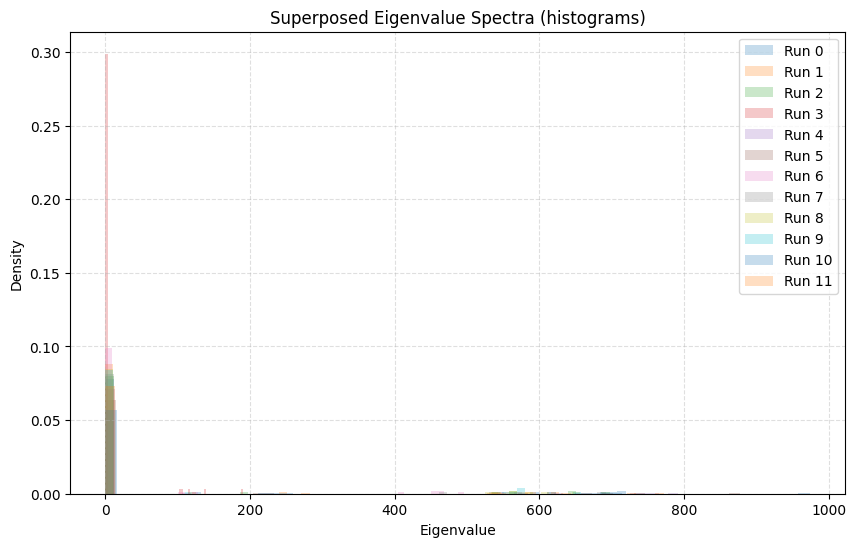

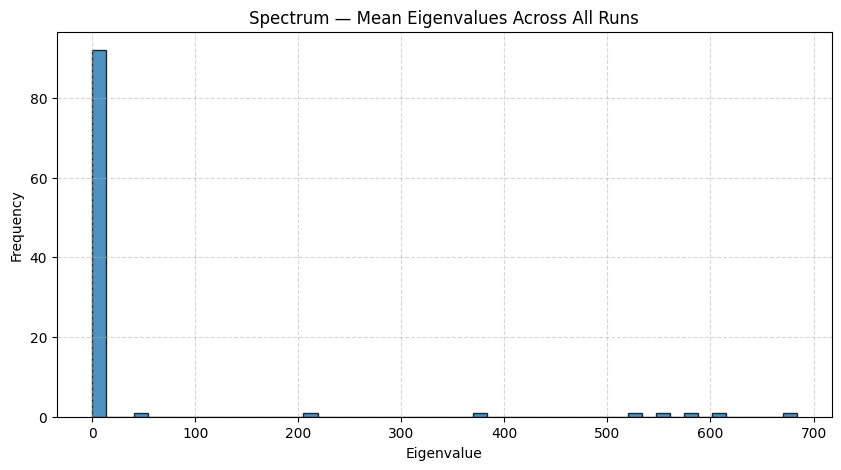

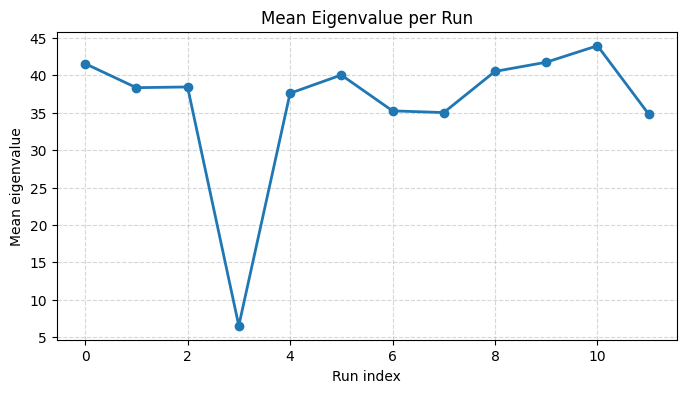

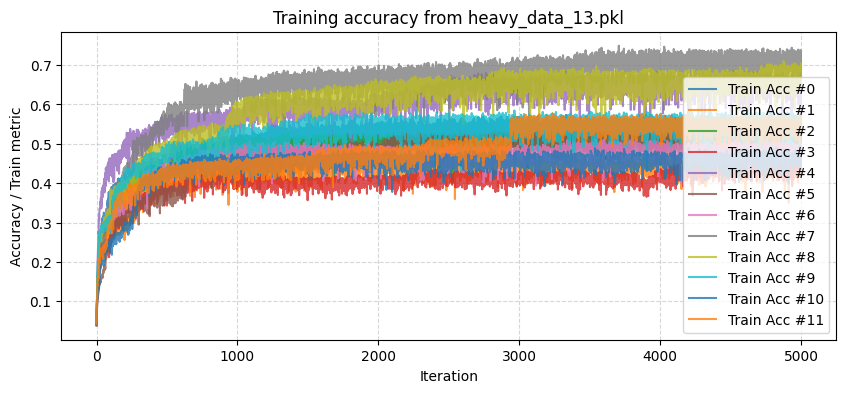

--- File: ../results/run_20251126_1019/heavy_data_14.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 36.224892


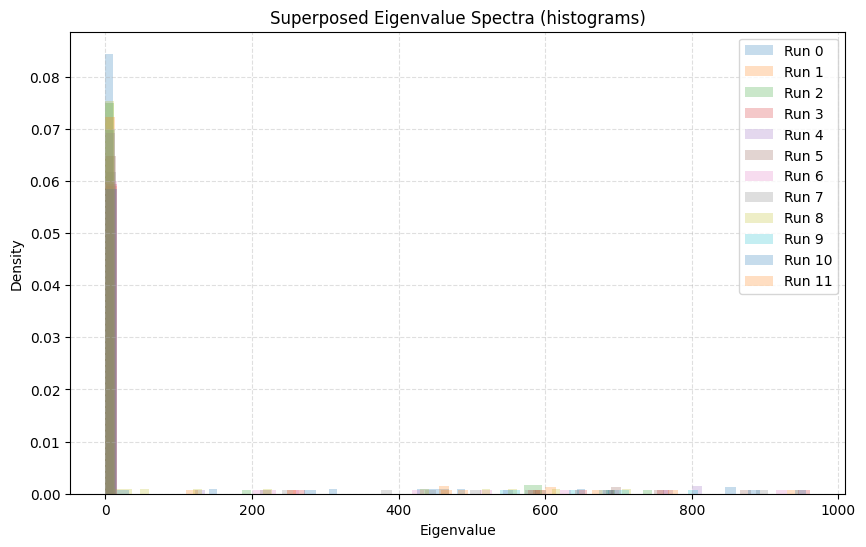

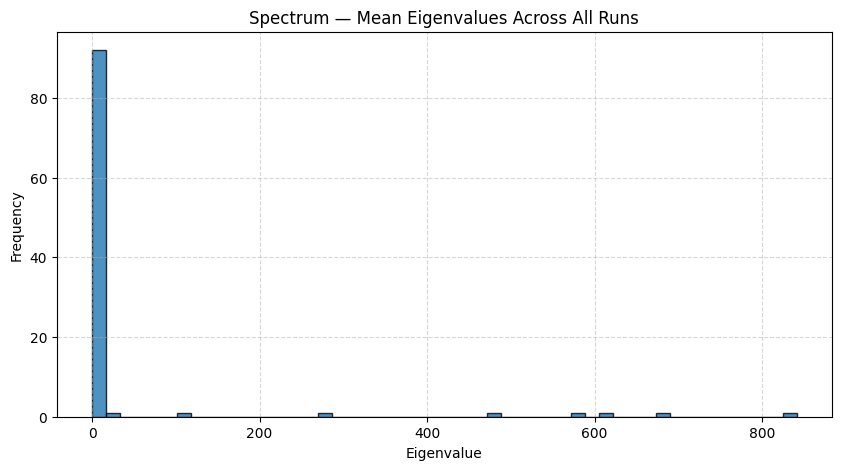

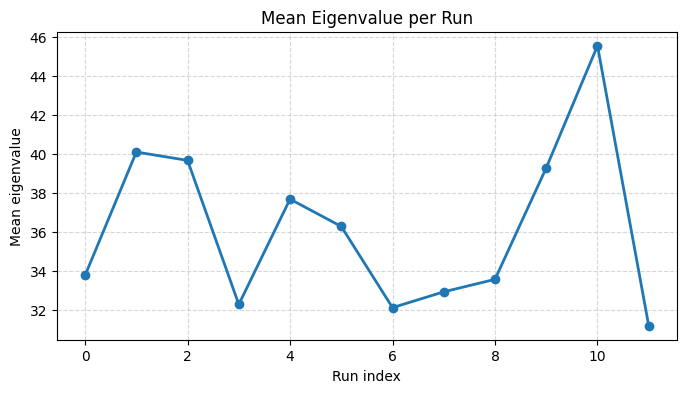

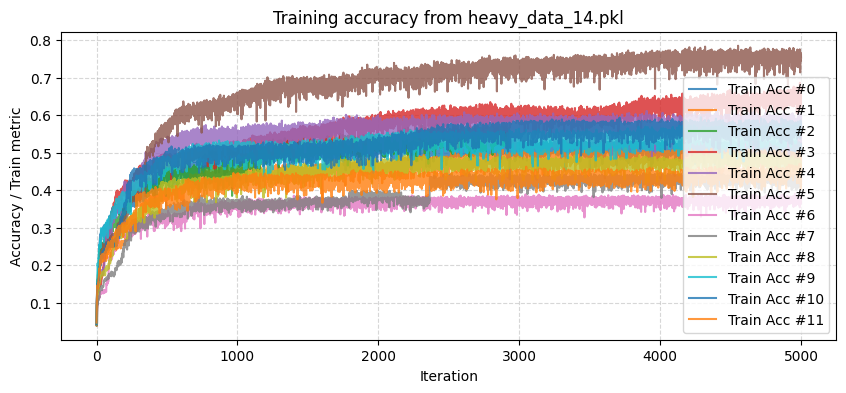

--- File: ../results/run_20251126_1019/heavy_data_2.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 37.461975


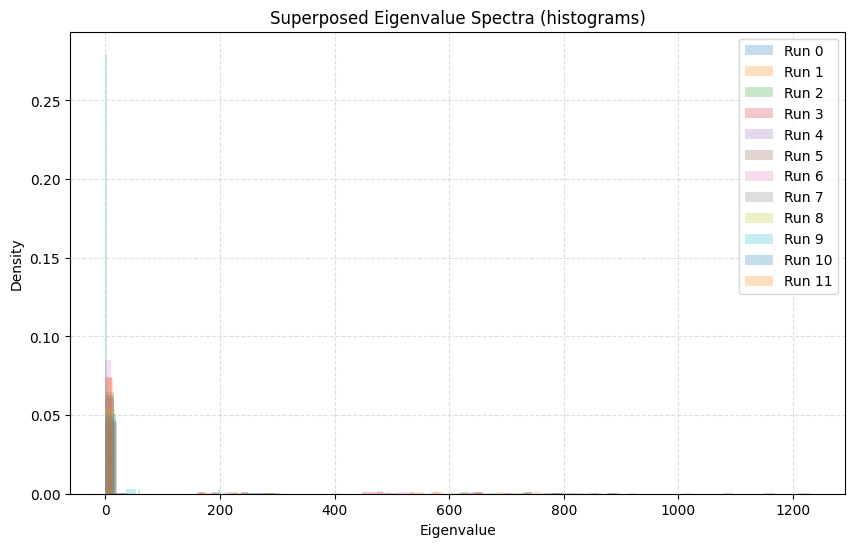

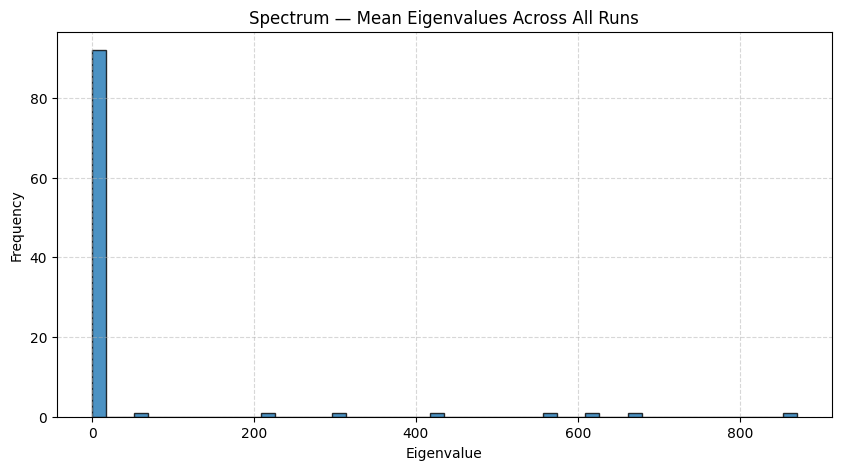

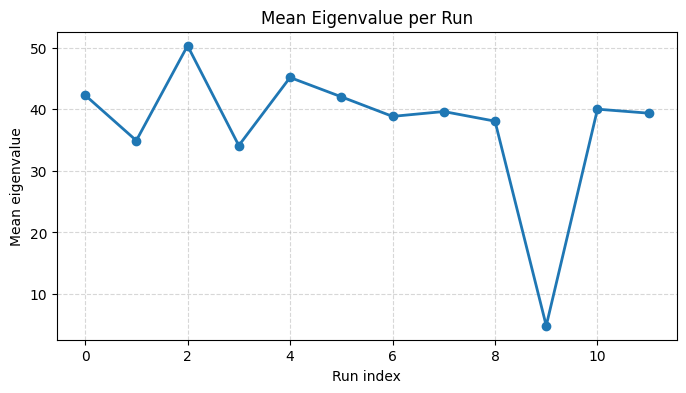

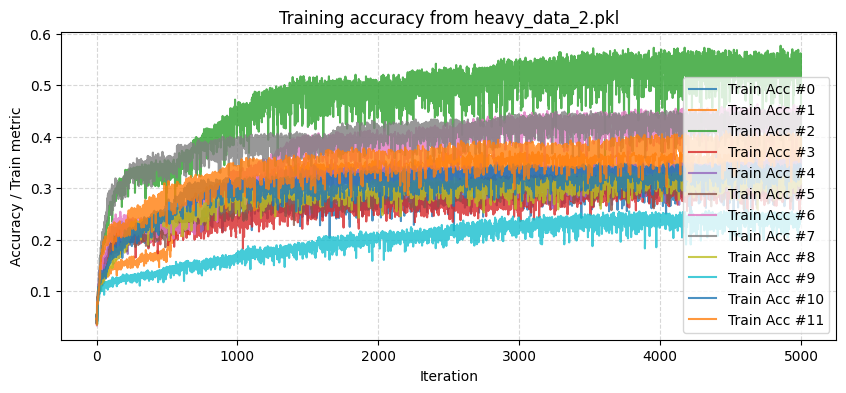

--- File: ../results/run_20251126_1019/heavy_data_3.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 38.688461


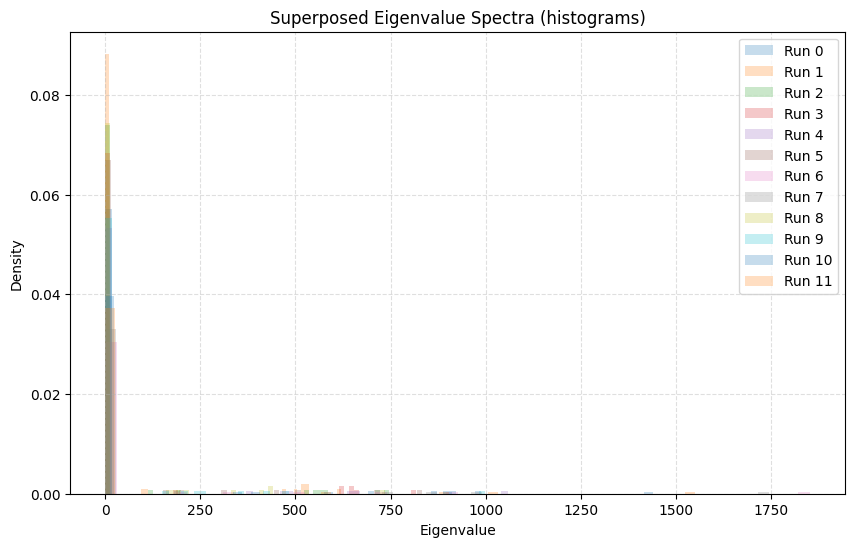

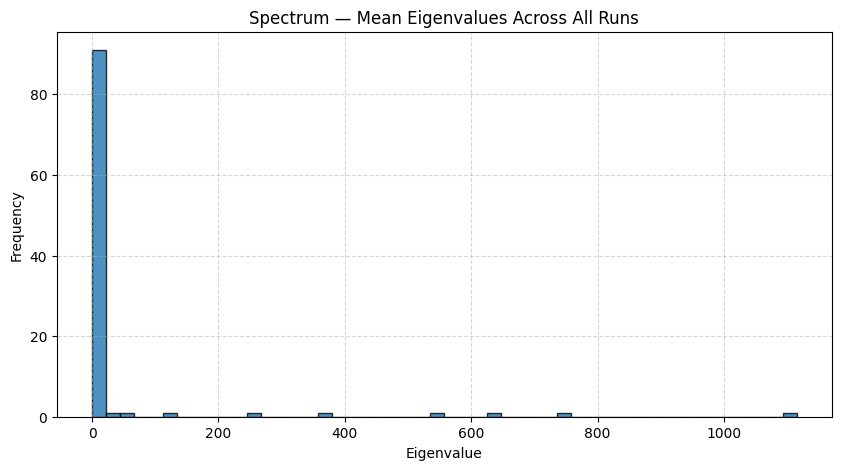

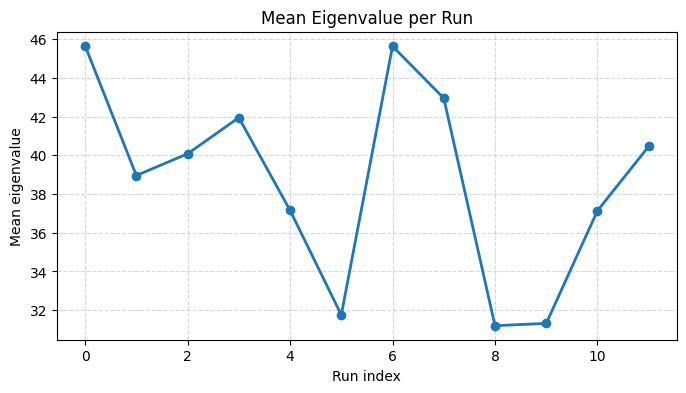

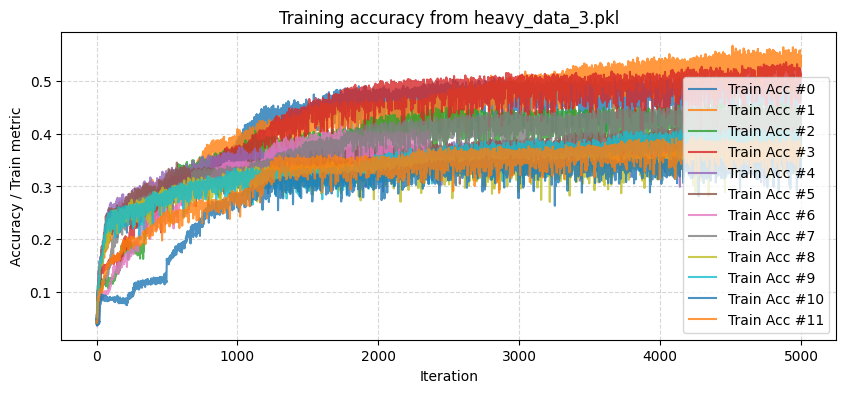

--- File: ../results/run_20251126_1019/heavy_data_4.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 37.003002


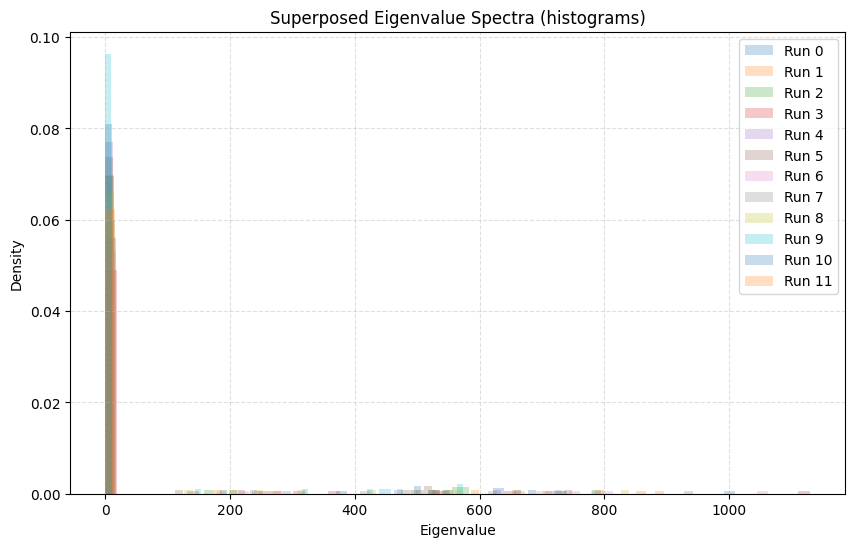

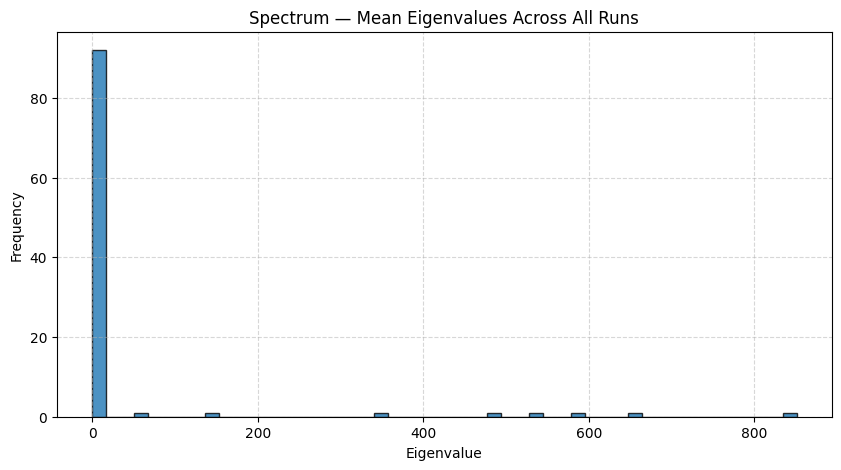

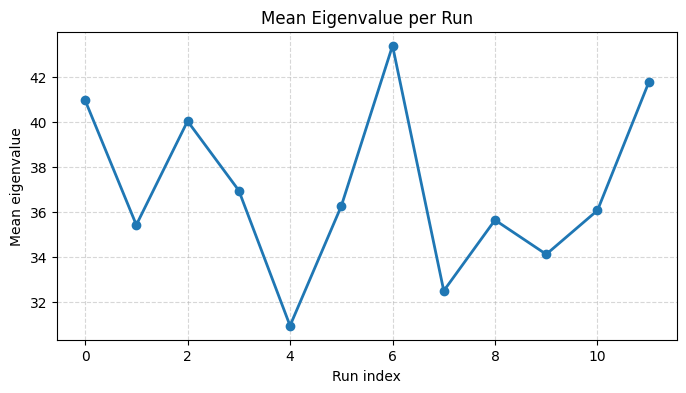

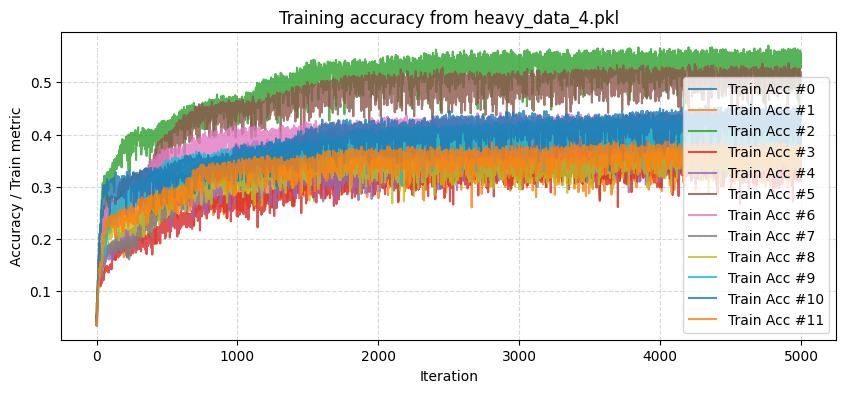

--- File: ../results/run_20251126_1019/heavy_data_5.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 35.852665


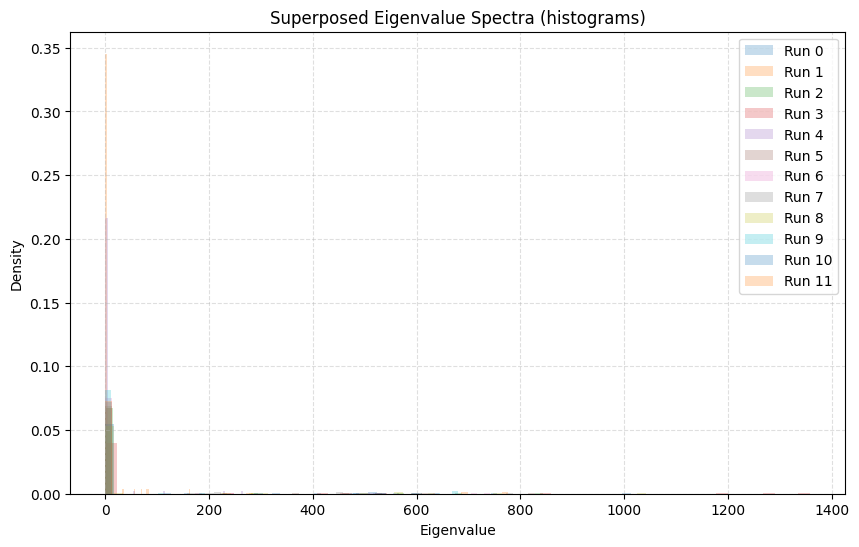

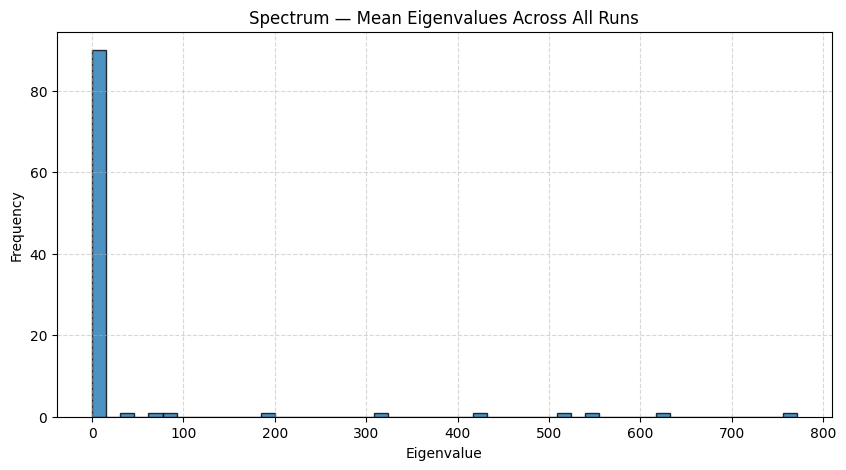

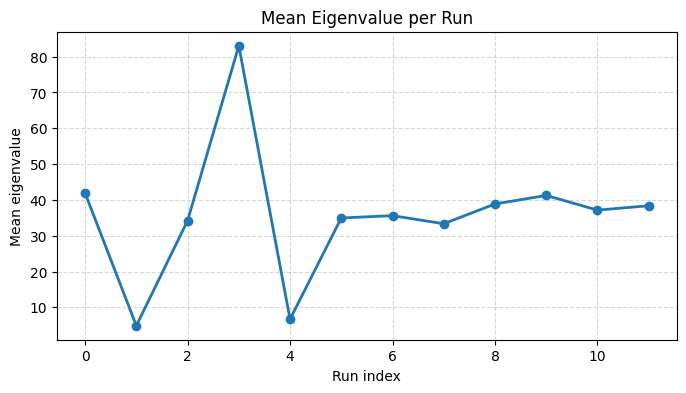

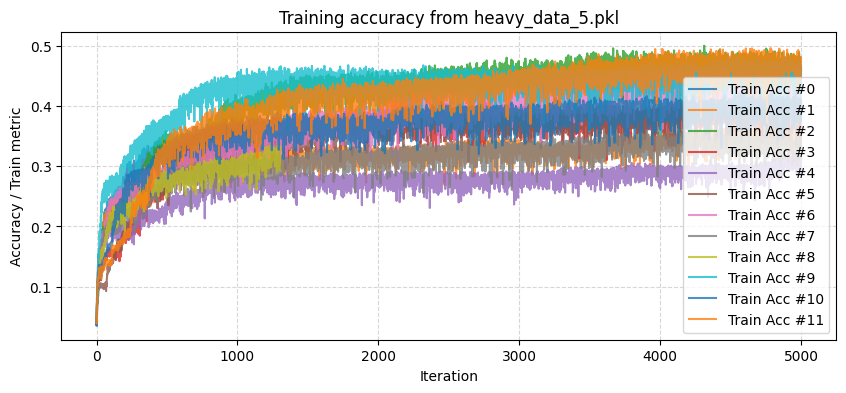

--- File: ../results/run_20251126_1019/heavy_data_6.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 36.997837


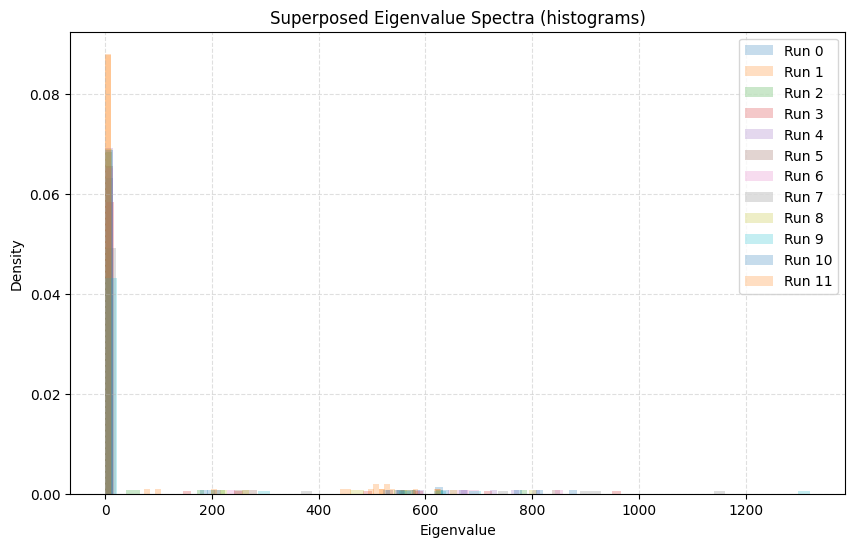

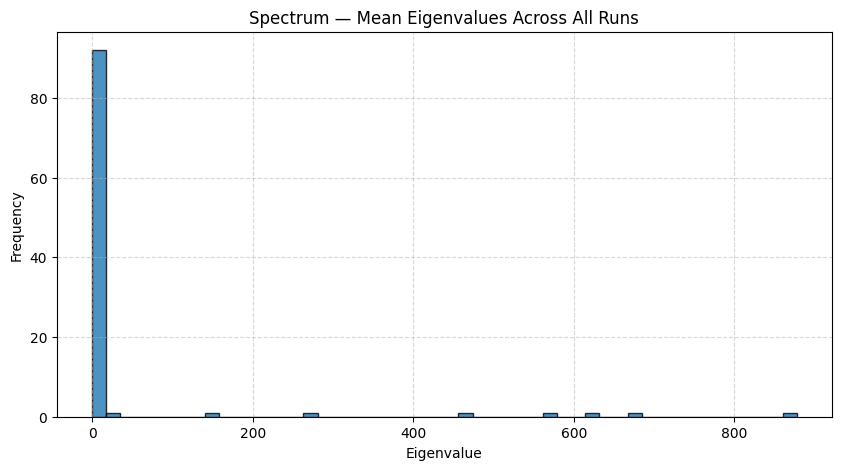

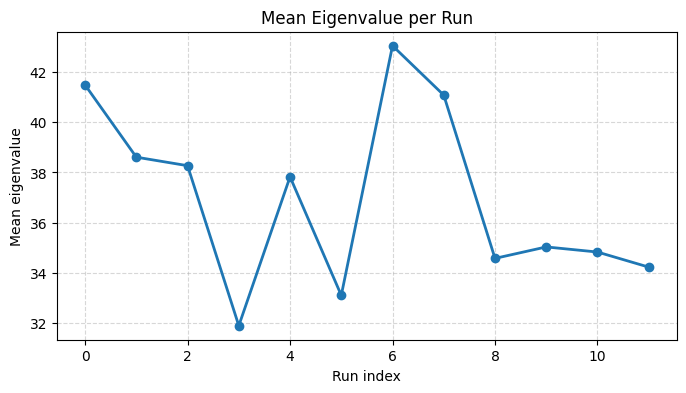

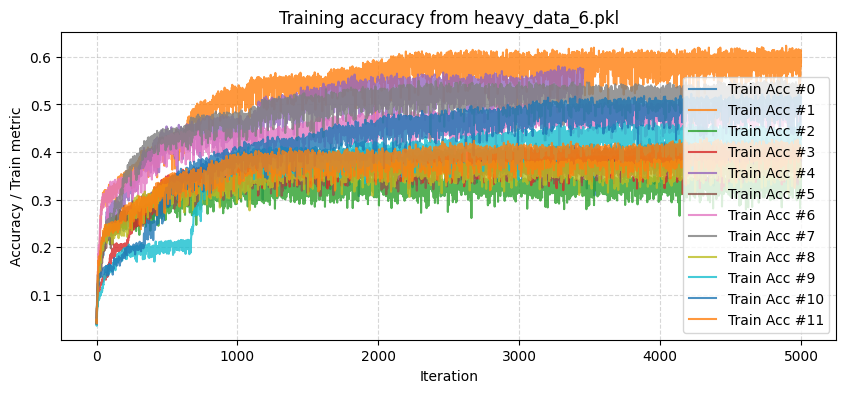

--- File: ../results/run_20251126_1019/heavy_data_7.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 37.883327


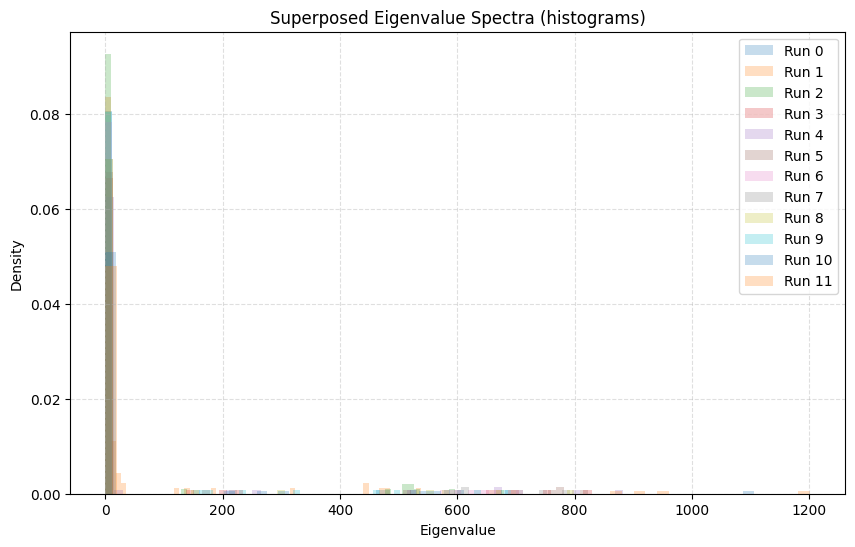

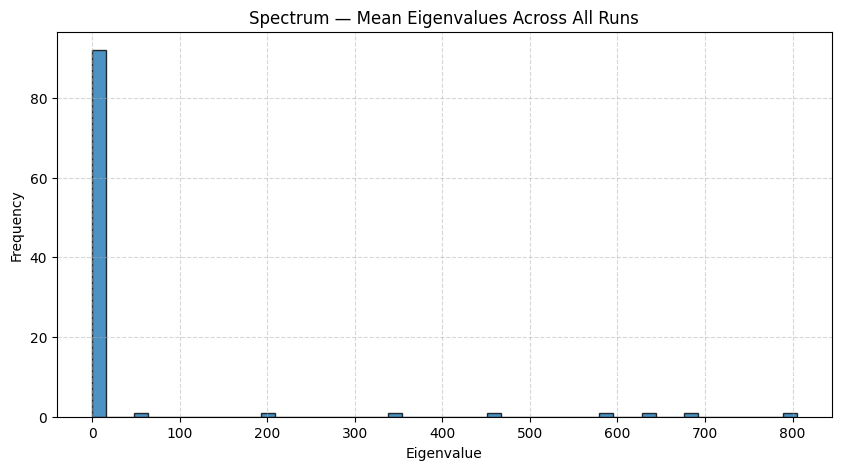

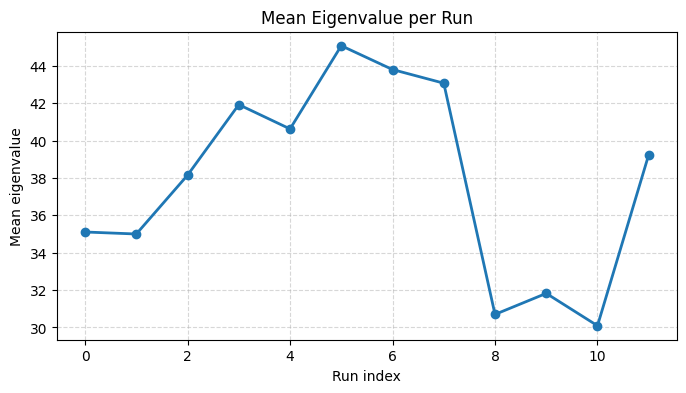

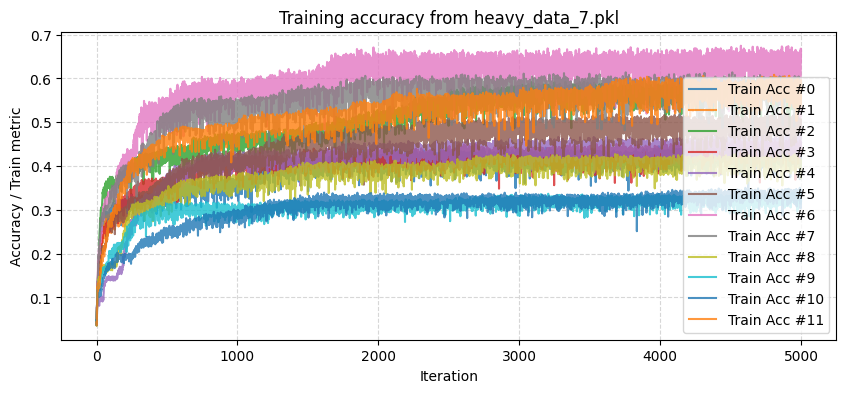

--- File: ../results/run_20251126_1019/heavy_data_8.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 37.358570


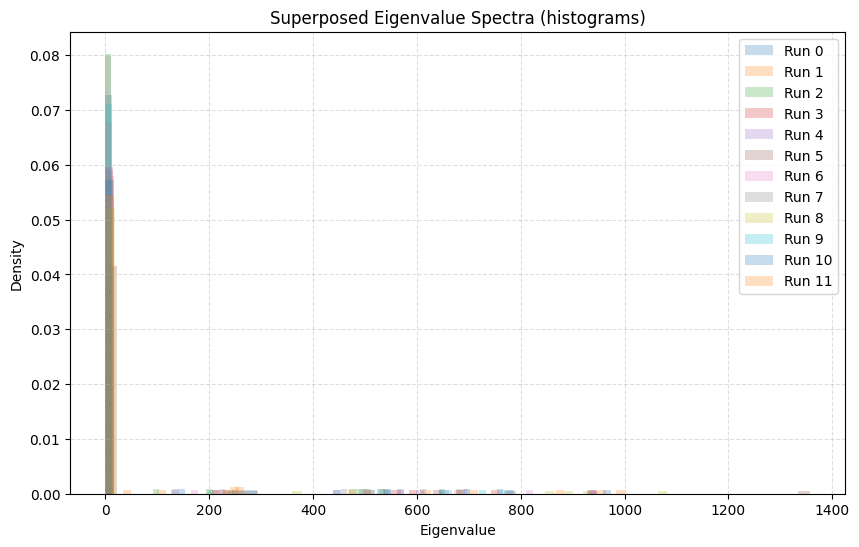

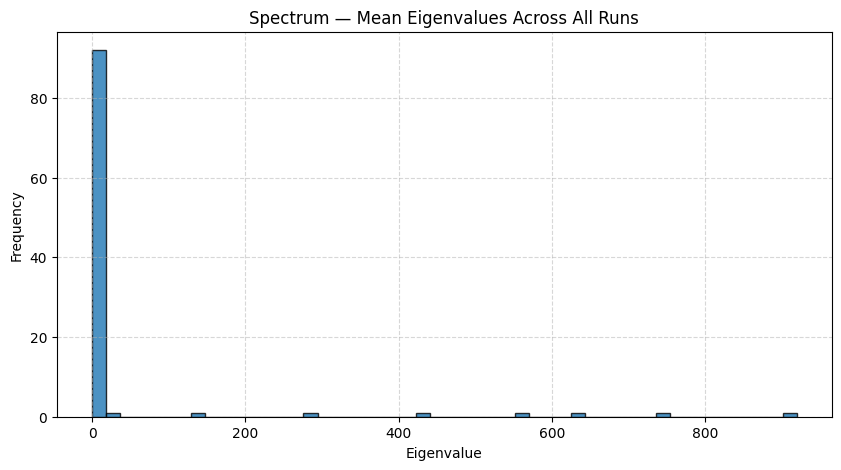

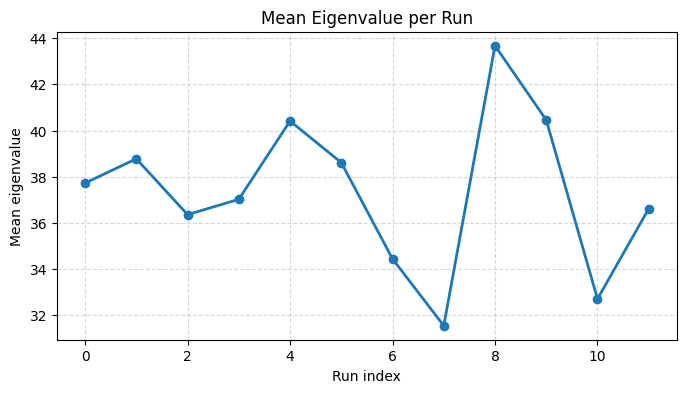

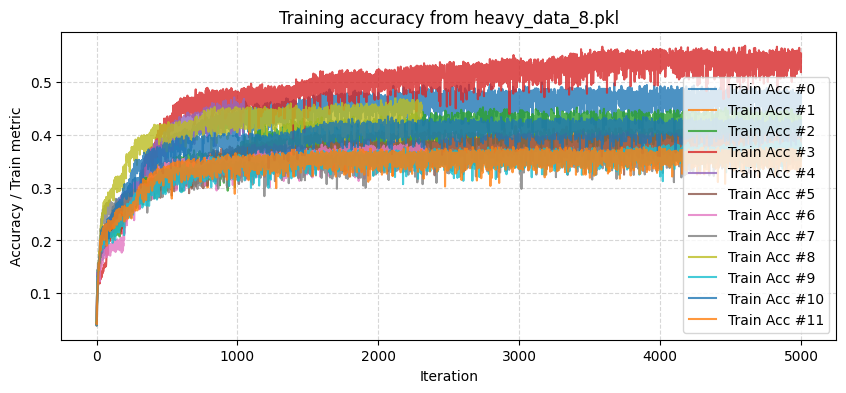

--- File: ../results/run_20251126_1019/heavy_data_9.pkl ---
W_runs: type=list, length=12
  first element shape: (100, 100), dtype=float32
attn_matrices: type=list, length=12
  first element shape: (2000, 30, 30), dtype=float32
seq_samples: type=list, length=12
  first element shape: (2000, 30), dtype=int64
y_samples: type=list, length=12
  first element shape: (2000, 30), dtype=float32
acc_train: type=list, length=12
  first element type: <class 'list'>


📊 Global mean of averaged eigenvalues = 31.733335


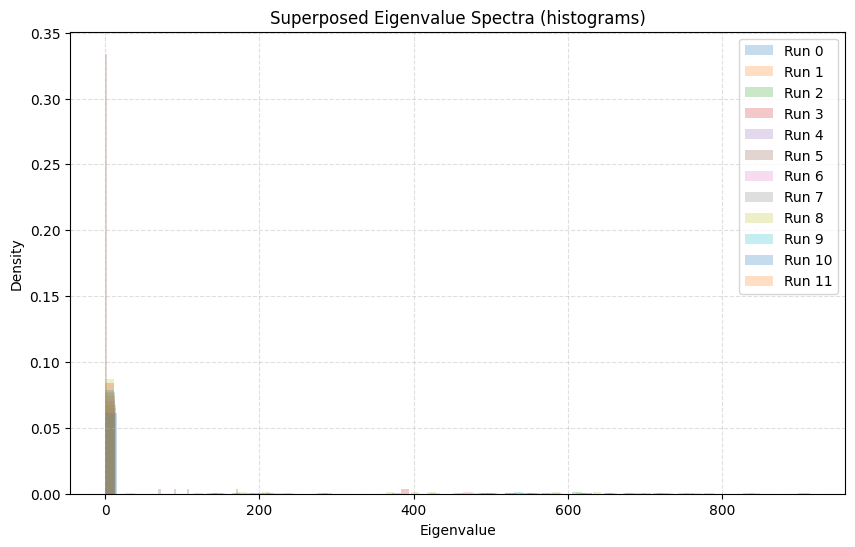

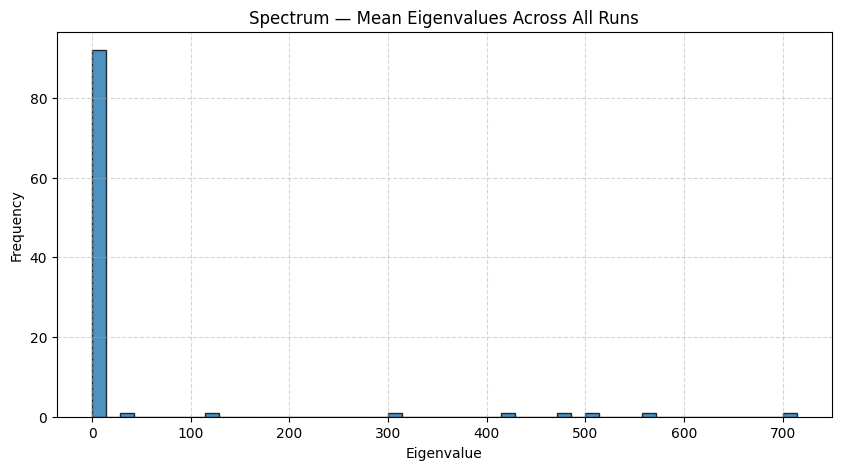

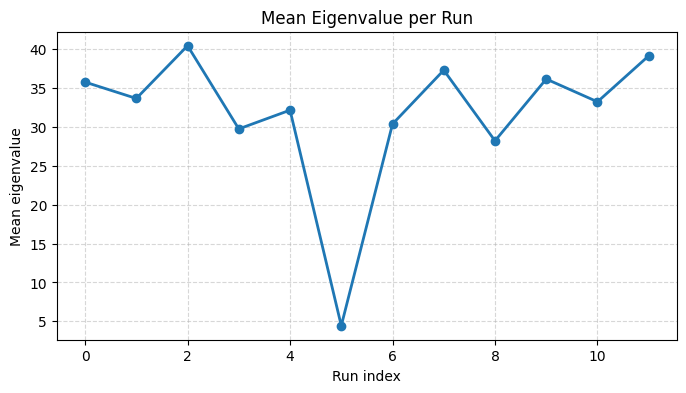

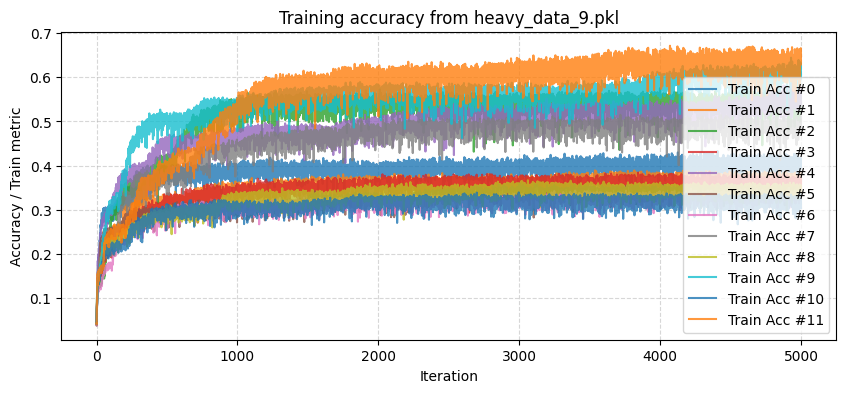

In [40]:
def highlight_diagonal(ax, seq_len, color='red', lw=2):
    """Draw rectangles along the diagonal of a matrix plot"""
    for i in range(seq_len):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, color=color, lw=lw)
        ax.add_patch(rect)

def plot_heavy_data_with_metrics(run_dir, max_plots=5, overlay_y_samples=True, show_shapes=True):
    """
    Plot eigenvalue spectra, attention matrices, sequence samples, and acc_train from the heavy_data pickle.
    Only plots up to max_plots λ values per run.
    overlay_y_samples: if True, plots y_samples overlay on attention matrices.
    show_shapes: if True, prints all keys with type/shape info.
    """
    heavy_files = sorted(glob.glob(os.path.join(run_dir, "heavy_data_*.pkl")))
    print(f"Found {len(heavy_files)} heavy_data files.\n")

    for heavy_file in heavy_files:
        print(f"--- File: {heavy_file} ---")
        with open(heavy_file, "rb") as f:
            data = pickle.load(f)
        
        if show_shapes:
            # Afficher toutes les clés et shape/type
            for key, val in data.items():
                if isinstance(val, np.ndarray):
                    print(f"{key}: type={type(val)}, shape={val.shape}, dtype={val.dtype}")
                elif isinstance(val, torch.Tensor):
                    print(f"{key}: type={type(val)}, shape={val.shape}, dtype={val.dtype}")
                elif isinstance(val, list):
                    print(f"{key}: type=list, length={len(val)}")
                    if len(val) > 0:
                        first = val[0]
                        if isinstance(first, np.ndarray):
                            print(f"  first element shape: {first.shape}, dtype={first.dtype}")
                        elif isinstance(first, torch.Tensor):
                            print(f"  first element shape: {first.shape}, dtype={first.dtype}")
                        else:
                            print(f"  first element type: {type(first)}")
                else:
                    print(f"{key}: type={type(val)}")
            print("\n")

        W_runs_all = data.get("W_runs", [])
        attn_matrices = data.get("attn_matrices", [])
        seq_samples = data.get("seq_samples", [])
        y_samples = data.get("y_samples", None)
        acc_train = data.get("acc_train", None)

        # --- Plots Eigenvalue & Attention ---
        # --- Compute eigenvalue spectra for all W ---
        eigvals_runs = []

        for W in W_runs_all:
            eigvals = np.linalg.eigvalsh(W @ W.T)
            eigvals_runs.append(eigvals)

        # --- Pad or truncate to match lengths (if needed) ---
        min_len = min(len(ev) for ev in eigvals_runs)
        eigvals_runs = np.array([ev[:min_len] for ev in eigvals_runs])

        # --- Mean eigenvalues per run ---
        mean_per_run = eigvals_runs.mean(axis=1)

        # --- Global mean of means (as requested) ---
        global_mean_mean = mean_per_run.mean()

        print(f"📊 Global mean of averaged eigenvalues = {global_mean_mean:.6f}")

        plt.figure(figsize=(10, 6))

        for i, W in enumerate(W_runs_all):
            eigvals = np.linalg.eigvalsh(W @ W.T)

            plt.hist(
                eigvals,
                bins=60,
                alpha=0.25,           # transparence pour superposer
                density=True,         # normalisation
                label=f"Run {i}"
            )

        plt.title("Superposed Eigenvalue Spectra (histograms)")
        plt.xlabel("Eigenvalue")
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.show()

        # --- Plot 1: Histogram of all eigenvalues averaged across runs ---
        plt.figure(figsize=(10, 5))
        plt.hist(eigvals_runs.mean(axis=0), bins=50, alpha=0.8, edgecolor="black")
        plt.title("Spectrum — Mean Eigenvalues Across All Runs")
        plt.xlabel("Eigenvalue")
        plt.ylabel("Frequency")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

        # --- Plot 2 (optional): per-run mean eigenvalues ---
        plt.figure(figsize=(8, 4))
        plt.plot(mean_per_run, marker='o', lw=2)
        plt.title("Mean Eigenvalue per Run")
        plt.xlabel("Run index")
        plt.ylabel("Mean eigenvalue")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

        # --- Plot acc_train ---
        if len(acc_train) > 0:
            plt.figure(figsize=(10,4))

            for i, acc_vals in enumerate(acc_train):
                # Convertir torch tensor / list en numpy
                if isinstance(acc_vals, list):
                    acc_vals = np.array(acc_vals)
                elif hasattr(acc_vals, "detach"):  # torch tensor
                    acc_vals = acc_vals.detach().cpu().numpy()

                plt.plot(acc_vals, lw=1.5, alpha=0.8, label=f"Train Acc #{i}")

            plt.xlabel("Iteration")
            plt.ylabel("Accuracy / Train metric")
            plt.title(f"Training accuracy from {os.path.basename(heavy_file)}")
            plt.grid(True, linestyle="--", alpha=0.5)
            plt.legend()
            plt.show()

# --- Usage ---
plot_heavy_data_with_metrics(run_dir, max_plots=5, overlay_y_samples=True, show_shapes=True)

Found 15 pickle files.


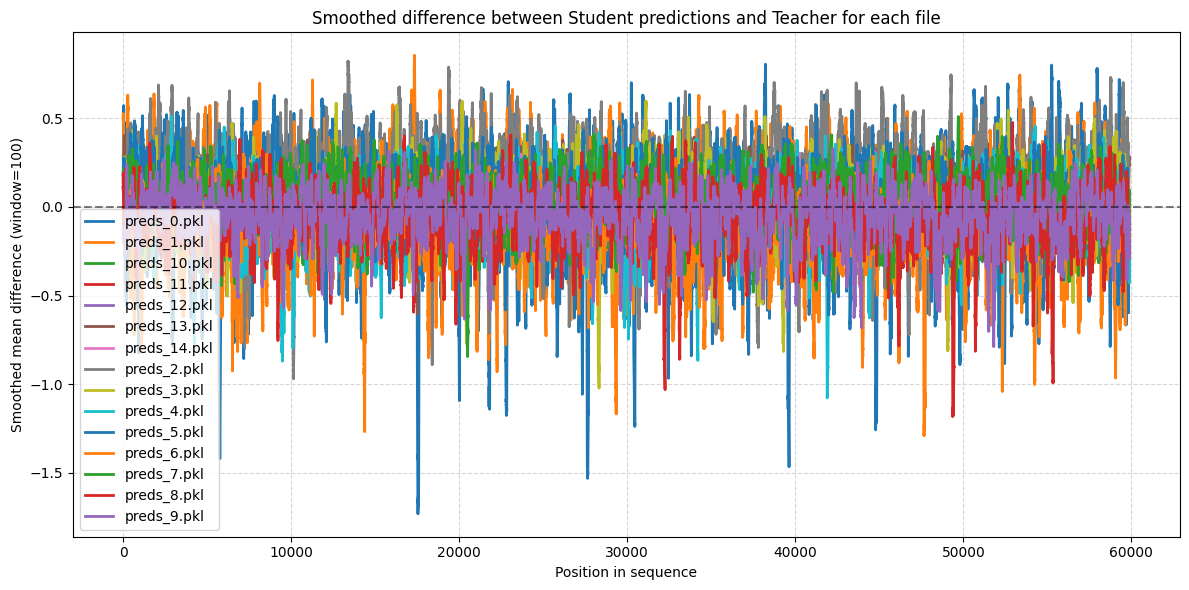

In [41]:
# --- Liste de tous les fichiers pickle ---
preds_pickle_files = sorted(glob.glob(os.path.join(run_dir, "preds_*.pkl")))
print(f"Found {len(preds_pickle_files)} pickle files.")

window_size = 100  # taille de la fenêtre de la moyenne glissante

plt.figure(figsize=(12, 6))

for path in preds_pickle_files:
    # --- Load pickle ---
    with open(path, "rb") as f:
        data = pickle.load(f)
    
    student_preds = data["student_pred_samples"]
    teacher_truth = data["teacher_true_samples"]
    
    # Flatten sequences
    student_preds_flat = [np.array(s).flatten() for s in student_preds]
    teacher_truth_flat = [np.array(t).flatten() for t in teacher_truth]
    
    # Compute difference for each sequence
    diffs = [s - t for s, t in zip(student_preds_flat, teacher_truth_flat)]
    
    # Compute mean difference across sequences in this file
    mean_diff = np.mean(np.stack(diffs), axis=0)
    
    # --- Apply moving average / rolling mean ---
    smoothed_diff = np.convolve(mean_diff, np.ones(window_size)/window_size, mode='valid')
    
    # Plot smoothed mean difference
    plt.plot(smoothed_diff, lw=2, label=os.path.basename(path))

plt.axhline(0, color='k', linestyle='--', alpha=0.5)  # zero line
plt.xlabel("Position in sequence")
plt.ylabel(f"Smoothed mean difference (window={window_size})")
plt.title("Smoothed difference between Student predictions and Teacher for each file")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()